# Notebook 2 — Survival Analysis of Case Duration
## Which factors determine how quickly bail cases are resolved?

Standard mean/median disposal time analyses **ignore pending cases**, treating them as if they don't exist.
This is a textbook **censoring bias**. Survival analysis is the statistically correct approach:
- Disposed cases: exact event time known
- Pending cases: censored — they haven't resolved yet, but we know they survived *at least* `PENDING_DAYS`

**Methods:** Kaplan-Meier estimator + Log-Rank tests + Cox Proportional Hazards model (lifelines)


In [6]:
# pip install lifelines
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("Compiled Bail case data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Cannot locate 'Compiled Bail case data.csv'. "
        "Place it next to this notebook."
    )
print(f"Data path: {DATA_PATH}")
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts


Data path: Compiled Bail case data.csv


## B. Load & Prepare Survival Data

In [7]:
COLS = ["NAME_OF_HIGH_COURT", "Mapped_Bail", "CURRENT_STATUS",
        "DISPOSAL_DAYS...1", "PENDING_DAYS", "HEARING_COUNT",
        "DATE_FILED", "YEAR"]
raw = pd.read_csv(DATA_PATH, usecols=COLS, low_memory=False)

raw["DISPOSAL_DAYS"] = pd.to_numeric(raw["DISPOSAL_DAYS...1"], errors="coerce")
raw["PENDING_DAYS"]  = pd.to_numeric(raw["PENDING_DAYS"],      errors="coerce")
raw["HEARING_COUNT"] = pd.to_numeric(raw["HEARING_COUNT"],     errors="coerce")

# Build survival dataset
raw["duration"] = np.where(
    raw["CURRENT_STATUS"] == "Disposed",
    raw["DISPOSAL_DAYS"],
    raw["PENDING_DAYS"]
)
raw["event"] = (raw["CURRENT_STATUS"] == "Disposed").astype(int)

# Remove rows with no duration info
df = raw.dropna(subset=["duration"]).copy()
df = df[df["duration"] > 0]

print(f"Survival dataset: {len(df):,} rows")
print(f"Events (disposed): {df['event'].sum():,} ({df['event'].mean()*100:.1f}%)")
print(f"Censored (pending): {(df['event']==0).sum():,} ({(df['event']==0).mean()*100:.1f}%)")


Survival dataset: 927,896 rows
Events (disposed): 876,982 (94.5%)
Censored (pending): 50,914 (5.5%)


## C. Kaplan-Meier by Bail Type + Log-Rank Test

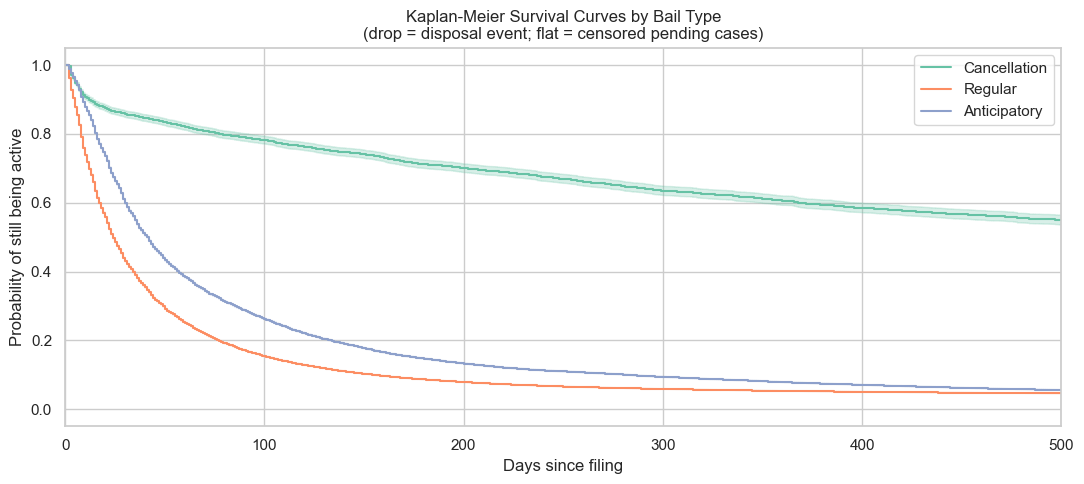

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
kmf = KaplanMeierFitter()
bail_types = df["Mapped_Bail"].dropna().unique()
label_map = {"REGULAR BAIL": "Regular", "ANTICIPATORY BAIL": "Anticipatory", "CANCELLATION": "Cancellation"}

for bail in bail_types:
    mask = df["Mapped_Bail"] == bail
    kmf.fit(df.loc[mask, "duration"], event_observed=df.loc[mask, "event"],
            label=label_map.get(bail, bail))
    kmf.plot_survival_function(ax=ax, ci_show=True, at_risk_counts=False)

ax.set_xlim(0, 500)
ax.set_xlabel("Days since filing")
ax.set_ylabel("Probability of still being active")
ax.set_title("Kaplan-Meier Survival Curves by Bail Type\n(drop = disposal event; flat = censored pending cases)")
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
# Log-Rank test: are KM curves significantly different?
groups = [
    df.loc[df["Mapped_Bail"] == b, ["duration", "event"]]
    for b in bail_types if b in df["Mapped_Bail"].values
]
result = multivariate_logrank_test(
    df["duration"], df["Mapped_Bail"].fillna("Unknown"), df["event"]
)
print(f"Multivariate Log-Rank test:")
print(f"  Test statistic: {result.test_statistic:.4f}")
print(f"  p-value:        {result.p_value:.2e}")
if result.p_value < 0.05:
    print("  v Bail type survival curves are SIGNIFICANTLY different (p < 0.05)")
else:
    print("  ✗ No significant difference between bail type survival curves")


Multivariate Log-Rank test:
  Test statistic: 25203.8746
  p-value:        0.00e+00
  v Bail type survival curves are SIGNIFICANTLY different (p < 0.05)


## D. Kaplan-Meier by High Court
Median survival time with 95% CI

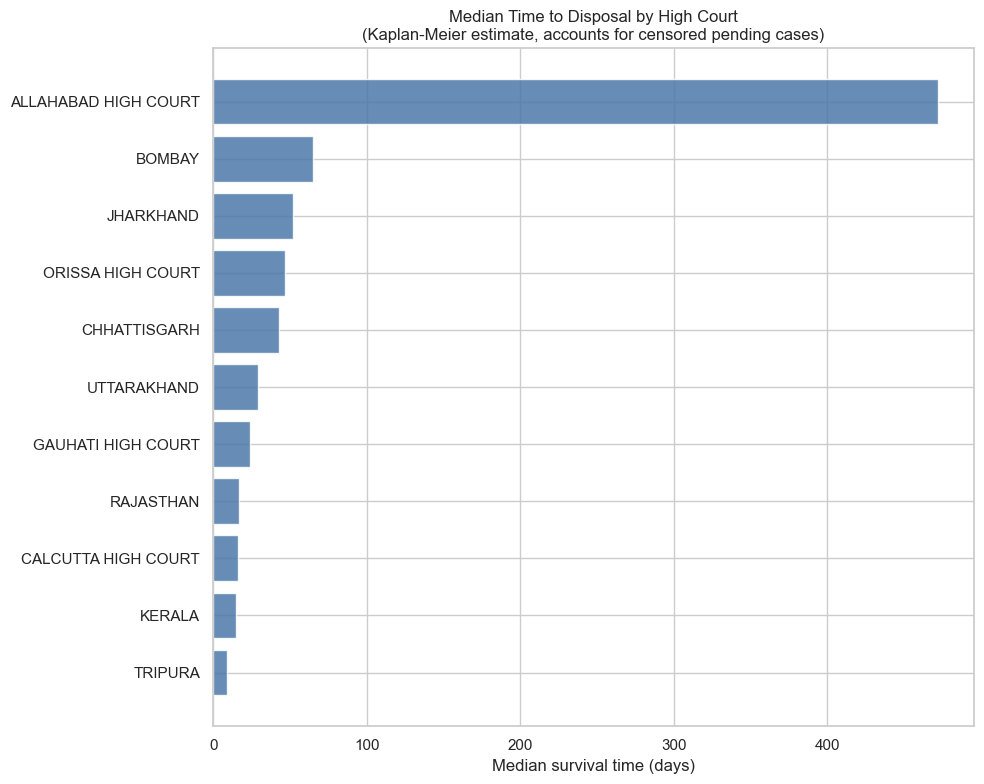

,court,median_survival_days,court_short
0,HIGH COURT OF TRIPURA,9.0,TRIPURA
1,HIGH COURT OF KERALA,15.0,KERALA
2,CALCUTTA HIGH COURT,16.0,CALCUTTA HIGH COURT
3,HIGH COURT OF RAJASTHAN,17.0,RAJASTHAN
4,THE GAUHATI HIGH COURT,24.0,GAUHATI HIGH COURT
5,HIGH COURT OF UTTARAKHAND,29.0,UTTARAKHAND
6,HIGH COURT OF CHHATTISGARH,43.0,CHHATTISGARH
7,ORISSA HIGH COURT,47.0,ORISSA HIGH COURT
8,HIGH COURT OF JHARKHAND,52.0,JHARKHAND
9,HIGH COURT OF BOMBAY,65.0,BOMBAY


In [14]:

# Only courts with ≥ 3000 cases for stable KM estimates
court_counts = df["NAME_OF_HIGH_COURT"].value_counts()
major_courts = court_counts[court_counts >= 3000].index.tolist()

km_results = {}
for court in major_courts:
    mask = df["NAME_OF_HIGH_COURT"] == court
    # Dropping NaNs to prevent KaplanMeierFitter errors
    data = df.loc[mask, ["duration", "event"]].dropna()
    
    kmf = KaplanMeierFitter()
    kmf.fit(data["duration"], event_observed=data["event"])
    km_results[court] = kmf.median_survival_time_

# Handle potential empty results and ensure compatibility with older pandas versions
km_df = pd.DataFrame.from_dict(km_results, orient='index', columns=['median_survival_days'])
km_df.index.name = 'court'
km_df = km_df.sort_values("median_survival_days").reset_index()

# Filter out infinite values (where median was not reached) for plotting
km_df = km_df[np.isfinite(km_df["median_survival_days"])]

km_df["court_short"] = (
    km_df["court"]
    .str.replace("HIGH COURT OF ", "", regex=False)
    .str.replace("THE ", "", regex=False)
    .str[:25]
)

if not km_df.empty:
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(km_df["court_short"], km_df["median_survival_days"], color="#4C78A8", alpha=0.85)
    ax.set_xlabel("Median survival time (days)")
    ax.set_title("Median Time to Disposal by High Court\n(Kaplan-Meier estimate, accounts for censored pending cases)")
    plt.tight_layout()
    plt.show()
    display(km_df)
else:
    print("No courts met the criteria or reached a median survival time.")



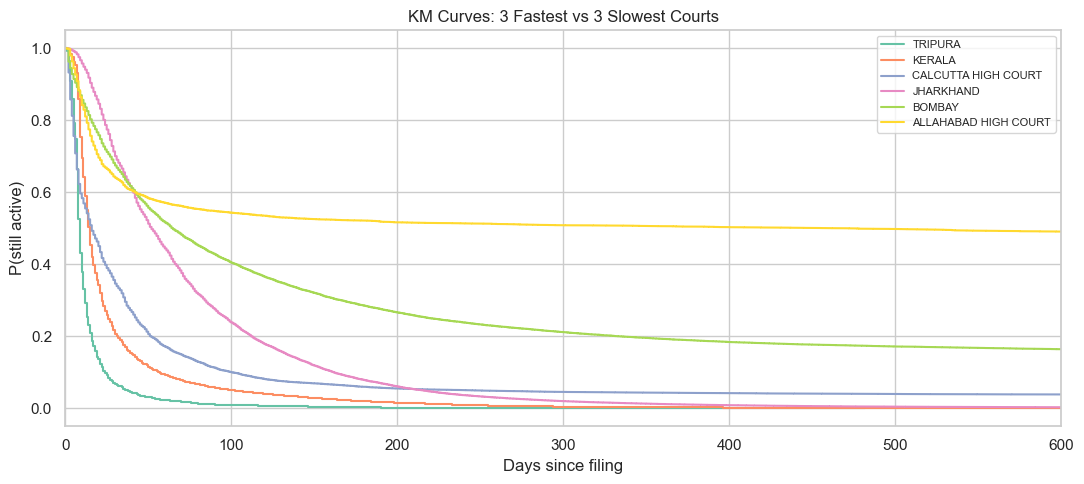

In [15]:
# KM curves for top 6 courts (fastest + slowest 3)
top3   = km_df.head(3)["court"].tolist()
bot3   = km_df.tail(3)["court"].tolist()
subset = top3 + bot3

fig, ax = plt.subplots(figsize=(11, 5))
for court in subset:
    mask = df["NAME_OF_HIGH_COURT"] == court
    label = court.replace("HIGH COURT OF ", "").replace("THE ", "")[:22]
    kmf2.fit(df.loc[mask, "duration"], event_observed=df.loc[mask, "event"], label=label)
    kmf2.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlim(0, 600)
ax.set_xlabel("Days since filing")
ax.set_ylabel("P(still active)")
ax.set_title("KM Curves: 3 Fastest vs 3 Slowest Courts")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## E. Cox Proportional Hazards Model
Hazard ratio > 1 means faster disposal (higher hazard of the event occurring)

In [16]:
# Prepare Cox dataset — limit to major courts for stability
cox_df = df[df["NAME_OF_HIGH_COURT"].isin(major_courts)].copy()
cox_df = cox_df.dropna(subset=["duration", "event", "Mapped_Bail", "HEARING_COUNT", "YEAR"])

# Encode categoricals for Cox model
bail_dummies = pd.get_dummies(cox_df["Mapped_Bail"], prefix="bail", drop_first=True)
court_dummies = pd.get_dummies(cox_df["NAME_OF_HIGH_COURT"], prefix="court", drop_first=True)

cox_input = pd.concat([
    cox_df[["duration", "event", "HEARING_COUNT", "YEAR"]].reset_index(drop=True),
    bail_dummies.reset_index(drop=True),
    court_dummies.reset_index(drop=True),
], axis=1)

cox_input["log_hearing"] = np.log1p(cox_input["HEARING_COUNT"])
cox_input = cox_input.drop(columns=["HEARING_COUNT"])

# Downsample for speed (Cox model is O(n log n) but 900K rows is slow)
if len(cox_input) > 200_000:
    cox_input = cox_input.sample(200_000, random_state=42)
    print(f"Downsampled to 200,000 rows for Cox model fitting.")

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_input, duration_col="duration", event_col="event", show_progress=True)


Downsampled to 200,000 rows for Cox model fitting.
Iteration 1: norm_delta = 5.22e-01, step_size = 0.9500, log_lik = -2137161.05425, newton_decrement = 2.15e+04, seconds_since_start = 0.4
Iteration 2: norm_delta = 9.02e-02, step_size = 0.9500, log_lik = -2116099.72338, newton_decrement = 5.38e+02, seconds_since_start = 0.6
Iteration 3: norm_delta = 1.21e-02, step_size = 0.9500, log_lik = -2115540.14443, newton_decrement = 1.30e+01, seconds_since_start = 0.8
Iteration 4: norm_delta = 5.78e-04, step_size = 1.0000, log_lik = -2115526.75243, newton_decrement = 3.00e-02, seconds_since_start = 1.0
Iteration 5: norm_delta = 1.56e-06, step_size = 1.0000, log_lik = -2115526.72238, newton_decrement = 2.19e-07, seconds_since_start = 1.3
Iteration 6: norm_delta = 1.17e-11, step_size = 1.0000, log_lik = -2115526.72238, newton_decrement = 1.27e-17, seconds_since_start = 1.5
Convergence success after 6 iterations.


<lifelines.CoxPHFitter: fitted with 200000 total observations, 10955 right-censored observations>

In [17]:
cph.print_summary(decimals=4)


<lifelines.CoxPHFitter: fitted with 200000 total observations, 10955 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 200000
number of events observed = 189045
   partial log-likelihood = -2115526.7224
         time fit was run = 2026-05-14 14:07:22 UTC

---
                                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                           
YEAR                              0.0048    1.0048    0.0008          0.0033          0.0063              1.0033              1.0063
bail_CANCELLATION                -0.9042    0.4049    0.0329         -0.9687         -0.8396              0.3796              0.4319
bail_REGULAR BAIL                 0.1022    1.1077    0.0059          0.0907          0.1138              1.0950              1.1205
court_CALCUTTA HIGH COURT         0.0432    1.0442    0.0097          0.0242          0.0623              1.0245              1.0642
court_HIGH COURT OF BOMBAY       -0.8018    0.4485    0.0116         -0.8245         -0.7792              0.4384              0.4588
court_HIGH COURT OF CHHATTISGARH  0.2340    1.2636    0.0172          0.2002          0.2677              1.2217              1.3070
court_HIGH COURT OF JHARKHAND     0.0345    1.0351    0.0085          0.0179          0.0511              1.0181              1.0525
court_HIGH COURT OF KERALA        0.9225    2.5157    0.0100          0.9029          0.9422              2.4667              2.5656
court_HIGH COURT OF RAJASTHAN     0.0472    1.0484    0.0090          0.0295          0.0649              1.0300              1.0671
court_HIGH COURT OF TRIPURA       1.3531    3.8692    0.0397          1.2752          1.4309              3.5795              4.1824
court_HIGH COURT OF UTTARAKHAND   0.4353    1.5454    0.0146          0.4066          0.4639              1.5018              1.5902
court_ORISSA HIGH COURT          -0.0514    0.9499    0.0085         -0.0681         -0.0348              0.9341              0.9658
court_THE GAUHATI HIGH COURT      0.6556    1.9262    0.0100          0.6360          0.6752              1.8889              1.9643
log_hearing                      -0.4644    0.6285    0.0038         -0.4718         -0.4570              0.6239              0.6332

                                  cmp to         z      p  -log2(p)
covariate                                                          
YEAR                              0.0000    6.2987 <5e-05   31.6333
bail_CANCELLATION                 0.0000  -27.4420 <5e-05  548.3258
bail_REGULAR BAIL                 0.0000   17.3753 <5e-05  222.2253
court_CALCUTTA HIGH COURT         0.0000    4.4462 <5e-05   16.8040
court_HIGH COURT OF BOMBAY        0.0000  -69.3086 <5e-05       inf
court_HIGH COURT OF CHHATTISGARH  0.0000   13.5882 <5e-05  137.2865
court_HIGH COURT OF JHARKHAND     0.0000    4.0714 <5e-05   14.3853
court_HIGH COURT OF KERALA        0.0000   91.9391 <5e-05       inf
court_HIGH COURT OF RAJASTHAN     0.0000    5.2349 <5e-05   22.5306
court_HIGH COURT OF TRIPURA       0.0000   34.0708 <5e-05  842.7700
court_HIGH COURT OF UTTARAKHAND   0.0000   29.8189 <5e-05  646.6250
court_ORISSA HIGH COURT           0.0000   -6.0482 <5e-05   29.3468
court_THE GAUHATI HIGH COURT      0.0000   65.5882 <5e-05       inf
log_hearing                       0.0000 -122.9746 <5e-05       inf
---
Concordance = 0.6929
Partial AIC = 4231081.4448
log-likelihood ratio test = 43268.6637 on 14 df
-log2(p) of ll-ratio test = inf

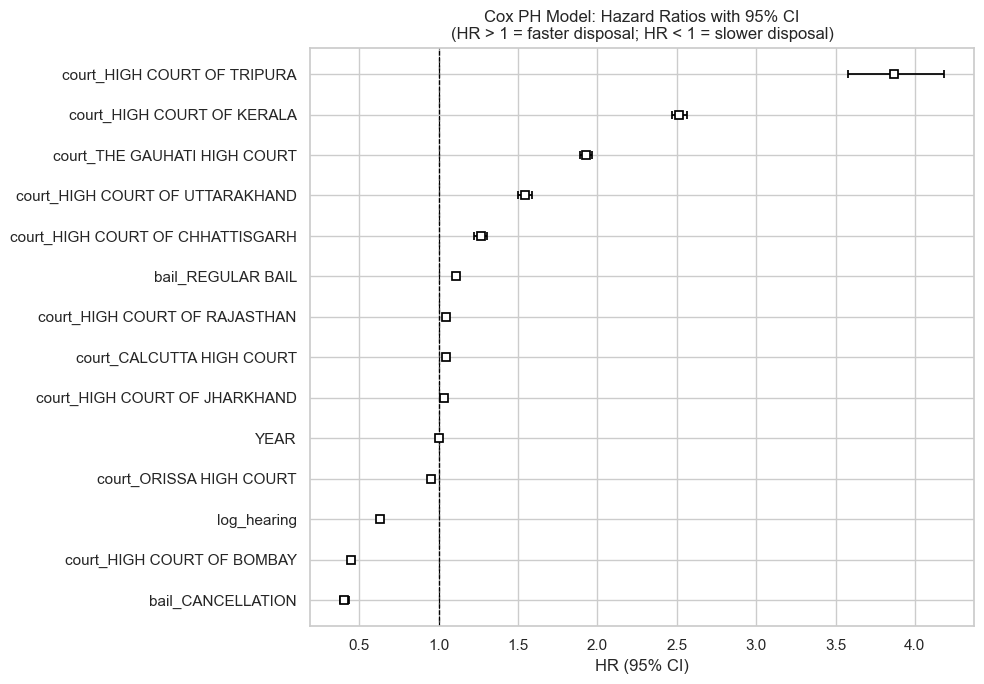

Hazard ratio: HR>1=faster disposal, HR<1=slower. Reference court=first alphabetically.


In [18]:
fig, ax = plt.subplots(figsize=(10, 7))
cph.plot(ax=ax, hazard_ratios=True)
ax.axvline(1, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Cox PH Model: Hazard Ratios with 95% CI\n(HR > 1 = faster disposal; HR < 1 = slower disposal)")
plt.tight_layout()
plt.show()
print("Hazard ratio: HR>1=faster disposal, HR<1=slower. Reference court=first alphabetically.")


## F. Proportional Hazards Assumption Check

In [19]:
# Schoenfeld residuals test — fit a small diagnostic model on 10K rows
try:
    from lifelines.statistics import proportional_hazard_test
    ph_sample = cox_input.sample(min(10_000, len(cox_input)), random_state=42).reset_index(drop=True)
    cph_diag = CoxPHFitter(penalizer=0.1)
    cph_diag.fit(ph_sample, duration_col="duration", event_col="event", show_progress=False)
    ph_test = proportional_hazard_test(cph_diag, ph_sample, time_transform="rank")
    ph_test.print_summary(decimals=3)
    print("Covariates with p < 0.05 violate the PH assumption and should be interpreted with caution.")
except Exception as e:
    print(f"PH test skipped: {e}")


<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 10000 total observations, 553 right-censored observations>
         test_name = proportional_hazard_test

---
                                  test_statistic      p  -log2(p)
YEAR                                       48.50 <0.005     38.14
bail_CANCELLATION                           7.64   0.01      7.46
bail_REGULAR BAIL                           3.41   0.06      3.95
court_CALCUTTA HIGH COURT                   0.94   0.33      1.59
court_HIGH COURT OF BOMBAY                 43.97 <0.005     34.80
court_HIGH COURT OF CHHATTISGARH           66.01 <0.005     50.98
court_HIGH COURT OF JHARKHAND             271.63 <0.005    200.31
court_HIGH COURT OF KERALA                  0.00   0.96      0.06
court_HIGH COURT OF RAJASTHAN               0.00   0.98      0.03
court_HIGH COURT OF TRIPURA                 0.55   0.46      1.12
court_HIGH COURT OF UTTARAKHAND            39.56 <0.005     31.55
court_ORISSA HIGH COURT                    51.95 <0.005     40.68
court_THE GAUHATI HIGH COURT               20.64 <0.005     17.46
log_hearing                               324.47 <0.005    238.56

Covariates with p < 0.05 violate the PH assumption and should be interpreted with caution.


# Key Findings

- The survival analysis was conducted on **9,27,896 bail cases**, including **8,76,982 disposed cases (94.5%)** and **50,914 pending cases (5.5%)**, allowing censored observations to be incorporated directly into the analysis.

- Kaplan–Meier estimates showed substantial variation in disposal duration across bail categories. The multivariate log-rank test produced a statistic of **25,203.87 (p < 0.001)**, confirming statistically significant differences in survival curves between bail types.

- Cancellation bail matters exhibited the slowest disposal patterns, while regular and anticipatory bail cases showed comparatively faster resolution probabilities over time.

- High Court-level survival curves demonstrated strong institutional heterogeneity, with materially different median disposal timelines across jurisdictions even after restricting analysis to courts with large case volumes.

- The Cox Proportional Hazards model was fitted on a stratified sample of **2,00,000 cases**, including **1,89,045 observed disposal events** and **10,955 censored observations**.

- Hearing count emerged as one of the strongest predictors of slower disposal, indicating that procedurally prolonged cases have substantially lower instantaneous disposal probabilities.

- Bail category, filing year, and High Court identity remained statistically significant even after multivariate adjustment, suggesting that disposal speed is shaped by both procedural complexity and institutional factors.

- The proportional hazards assumption was partially violated for some covariates (notably filing year and certain bail categories), indicating that the effect of these variables changes over time rather than remaining constant throughout the case lifecycle.

# Limitations

- The dataset captures administrative metadata rather than detailed judicial reasoning, factual complexity, advocate quality, or evidentiary strength.

- Survival estimates depend on the accuracy of `DISPOSAL_DAYS...1` and `PENDING_DAYS`, which are derived variables generated during DAKSH preprocessing.

- High Court procedures are not standardized nationally; therefore, differences in listing practices, adjournment culture, and registry workflows may influence estimated survival patterns.

- The Cox model assumes proportional hazards, but diagnostic testing showed partial violations for some predictors, meaning coefficient interpretations should be treated as approximate rather than time-invariant.

- Only cases available through the eCourts-based DAKSH pipeline were analyzed, so missing or inconsistently digitized records may affect representativeness.